# Neural Network Regression: Building Energy Consumption Prediction

Use case: **Predict building heating load (energy consumption)**.

Dataset: UCI Energy Efficiency Dataset

Problem type: Regression

Goal: Predict **Heating Load** of buildings based on architectural features.

This notebook demonstrates a complete ML workflow:

1. Load dataset directly from URL
2. Explore dataset
3. Prepare features
4. Train/Test split
5. Feature scaling
6. Train Neural Network
7. Evaluate predictions


## Install Required Libraries

In [1]:
!pip install pandas numpy scikit-learn tensorflow matplotlib seaborn

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras

## Load Dataset

Dataset source:
UCI Energy Efficiency Dataset

It contains building parameters and their heating/cooling energy requirements.

In [3]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx'

df = pd.read_excel(url)

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## Dataset Shape

In [4]:
df.shape

(768, 10)

## Column Names

In [5]:
df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')

## Rename Columns for Simplicity

In [6]:
df.columns = [
'RelativeCompactness',
'SurfaceArea',
'WallArea',
'RoofArea',
'OverallHeight',
'Orientation',
'GlazingArea',
'GlazingAreaDistribution',
'HeatingLoad',
'CoolingLoad'
]

In [7]:
df.head()

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## Target Variable

We will predict:

HeatingLoad

In [8]:
y = df['HeatingLoad']

X = df.drop(['HeatingLoad','CoolingLoad'], axis=1)

## Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Build Neural Network Model

In [11]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1) #we usually DO NOT specify an activation function in the last layer for regression
])

## Compile Model

In [14]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

## Train Model

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.5264 - mae: 1.2645 - val_loss: 3.2068 - val_mae: 1.2732
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.0076 - mae: 1.1450 - val_loss: 3.1877 - val_mae: 1.2892
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3383 - mae: 1.2591 - val_loss: 3.4791 - val_mae: 1.3283
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8979 - mae: 1.1661 - val_loss: 3.1390 - val_mae: 1.2906
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2486 - mae: 1.2361 - val_loss: 3.0634 - val_mae: 1.2785
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0119 - mae: 1.1782 - val_loss: 3.0461 - val_mae: 1.2446
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2870 - mae: 1.0681 - val_loss: 2.8472 - val_mae: 1.2264
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8926 - mae: 1.1913 - val_loss: 3.0346 - val_mae: 1.2525
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.839

## Model Evaluation

In [16]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print('MAE:', mae)
print('RMSE:', rmse)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
MAE: 0.46899590948030534
RMSE: 0.5803145703082293


## Actual vs Predicted Plot

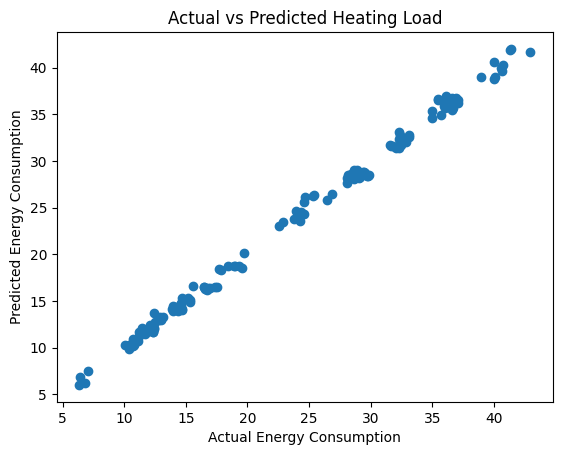

In [17]:
plt.scatter(y_test, pred)
plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Actual vs Predicted Heating Load')
plt.show()